# Training-Free Text-to-Image Generation via Token Search

FlexTok encodes images into 256 discrete tokens ordered in a coarse-to-fine manner. This structure enables not only autoregressive generation but also pure search-based generation using only a text-image verifier and random token sampling, without requiring an AR model.

This notebook covers:
- **Section 1** — Visualize FlexTok's visual vocabulary and coarse-to-fine token structure
- **Section 2** — Zero-shot image generation by beam search over uniformly sampled tokens (no AR model, no training)

In [1]:
import sys, os
import warnings
import logging
import io
import contextlib

# Suppress warnings/logs before importing third-party packages
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("l3m").setLevel(logging.ERROR)    # suppress MoE import message

import numpy as np
import torch
import transformers
import torchvision.transforms.functional as TF
transformers.utils.logging.set_verbosity_error()
logging.getLogger("soto").setLevel(logging.INFO)     # keep soto model loading / search progress

# Wrap imports to suppress print() noise from third-party packages
with contextlib.redirect_stdout(io.StringIO()):
    from flextok.flextok_wrapper import FlexTokFromHub
    from flextok.utils.demo import batch_to_pil, denormalize
    from flextok.utils.misc import detect_bf16_support, get_bf16_context, get_generator
    from soto.ar_priors.base import ARPriorFactory
    from soto.verifiers.base import VerifierFactory
    from soto.search_algorithms.base import SearchAlgorithmFactory
    from soto.utils.viz import load_img, show_images, show_rows, show_search_tree

FIXED_SEED = 0
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:0


## 1. The Visual Vocabulary of FlexTok

FlexTok uses a Finite Scalar Quantization (FSQ) codebook with 64,000 tokens and a token sequence length of 256. Early tokens capture more global concepts, while later tokens capture more detailed concepts.

Below, we provide some interactive examples to illustrate the "visual vocabulary" of FlexTok and the relationship between early and later tokens, providing better context before introducing generation via search.

In [2]:
# Load the FlexTok tokenizer directly (not the SoTo AR wrapper) to access
# its tokenize/detokenize interface for vocabulary visualization.
flextok = FlexTokFromHub.from_pretrained('EPFL-VILAB/flextok_d18_d28_dfn').to(device).eval()

### 1.1 Single-Token Vocabulary Visualization

We sample random token IDs from the 64,000-token vocabulary and decode each as a single-token sequence. Decoding the same token with different random seeds produces images with consistent global structure but varying fine details, illustrating the distribution captured by that token.

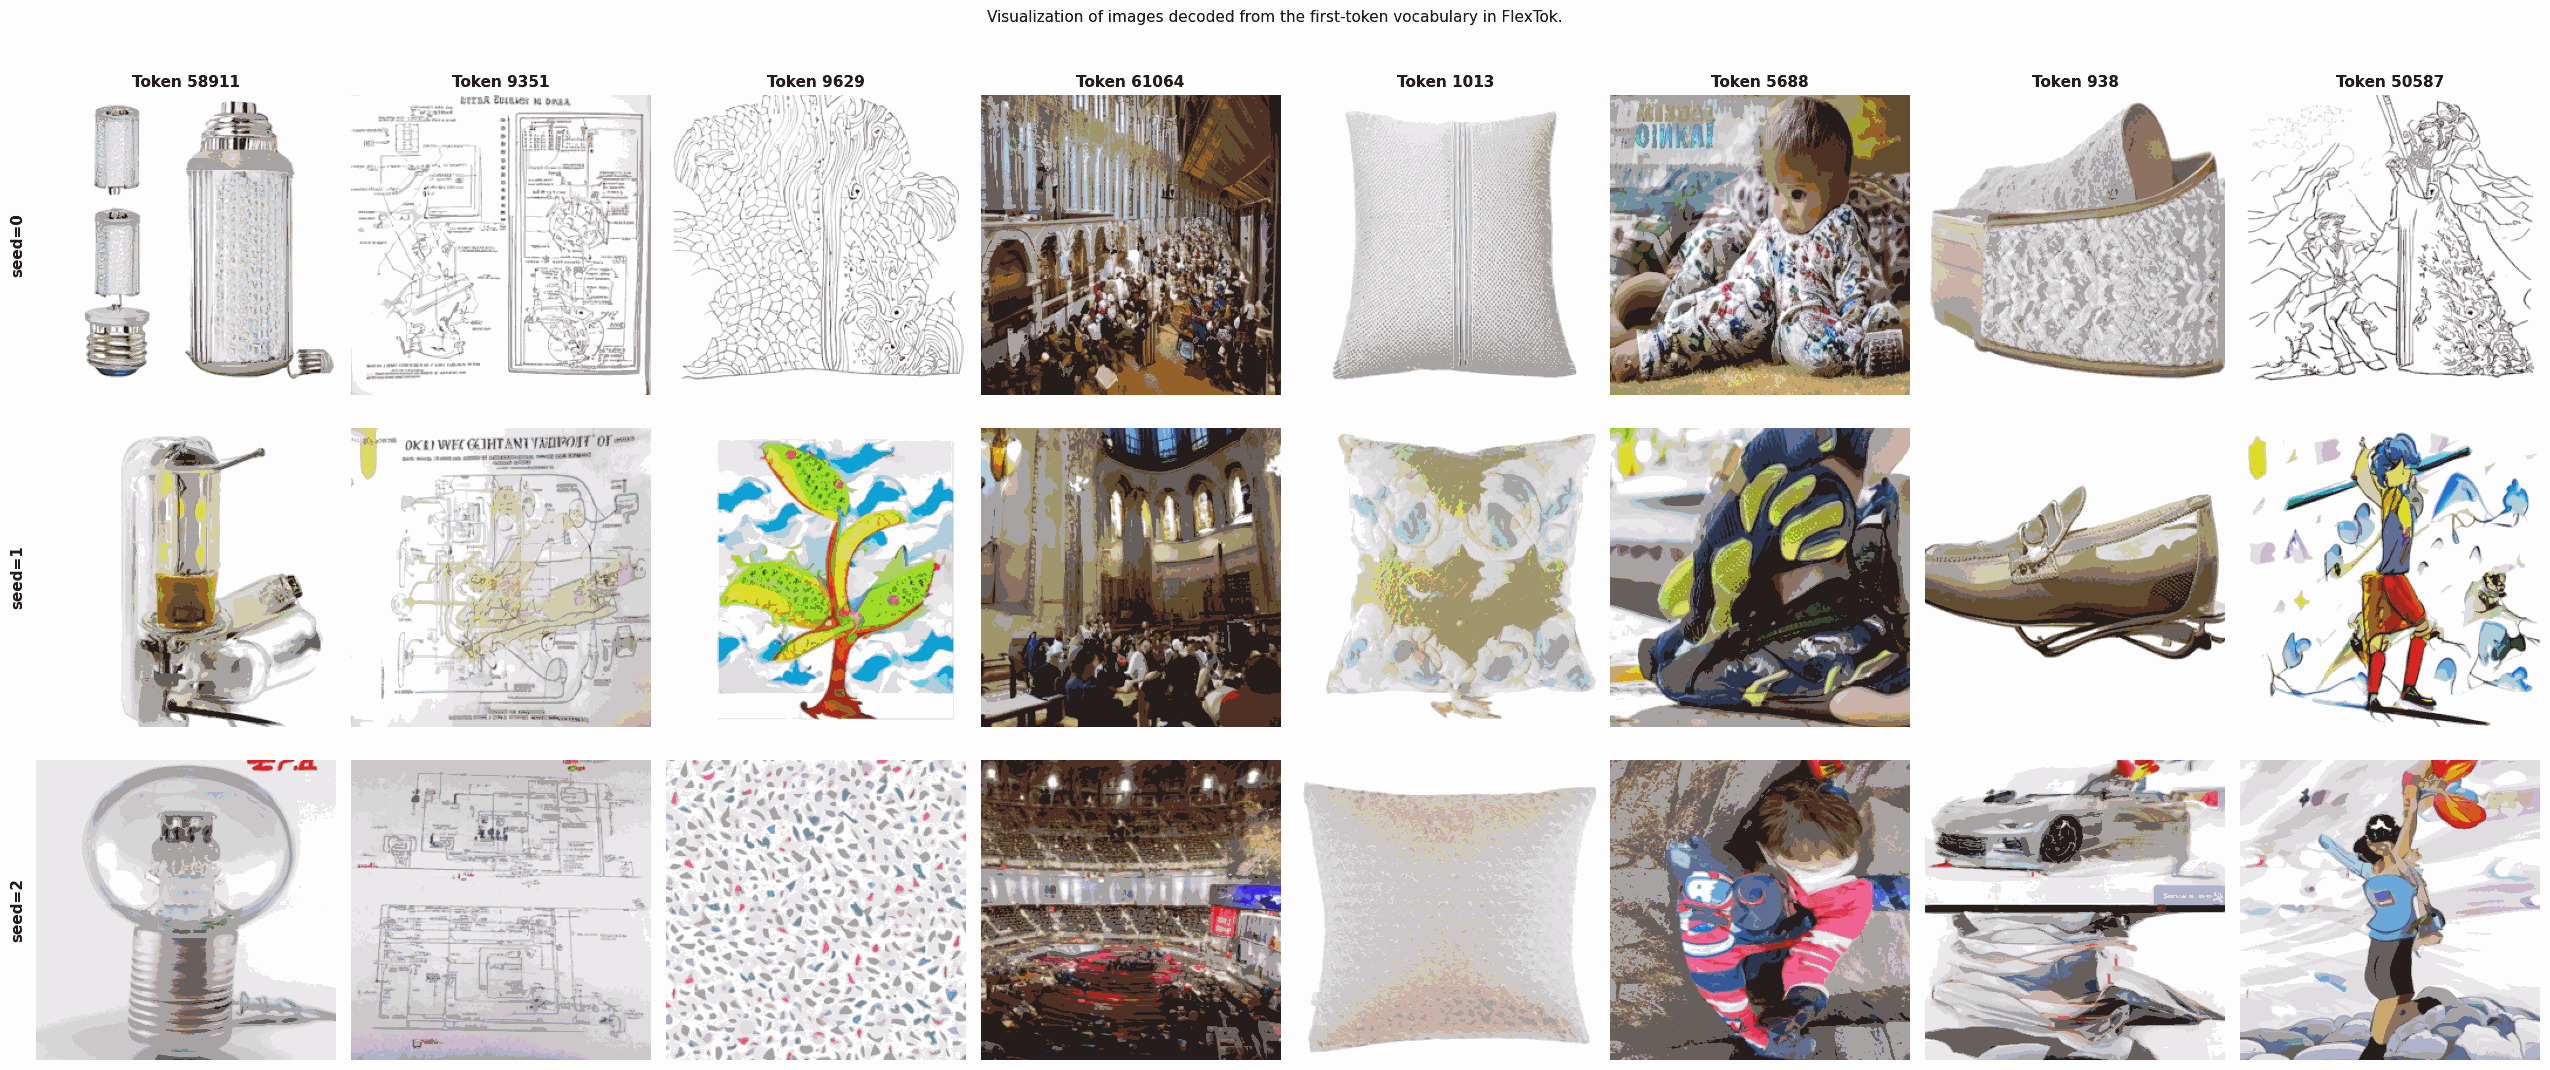

In [3]:
n_tokens = 8
n_seeds = 3
token_ids = np.random.randint(0, 64000, size=n_tokens)   # Feel free to replace with other token IDs

# Decode each token with each seed
decoded = {}
for tok_idx, token_id in enumerate(token_ids):
    t = torch.tensor([[token_id]], device=device)  # [1, 1]
    for seed in range(n_seeds):
        generator = torch.Generator(device=device).manual_seed(seed)
        decoded[(tok_idx, seed)] = flextok.detokenize(
            [t], timesteps=25, guidance_scale=7.5, perform_norm_guidance=True,
            generator=generator, verbose=False)

show_rows(
    [(f"seed={s}", [batch_to_pil(decoded[(i, s)]) for i in range(n_tokens)], None)
     for s in range(n_seeds)],
    col_titles=[f"Token {tid}" for tid in token_ids],
    title="Visualization of images decoded from the first-token vocabulary in FlexTok.",
)

# We also provide a demo for visualizing the first token distribution and their detokenized images on the website, feel free to check it out.

### 1.2 Coarse-to-Fine Structure on a Real Image

We tokenize a real image into 256 FlexTok tokens, then decode it at increasing prefix lengths (1, 2, 4, …, 256 tokens) using multiple random seeds. This shows that:
- Early tokens capture global semantic information and gradually refine color, layout, etc., as more tokens are added.
- All seeds produce the same overall concept but diverge in details, indicating that each token represents a distribution.

First 4 tokens: [22976, 6636, 61409, 15209]


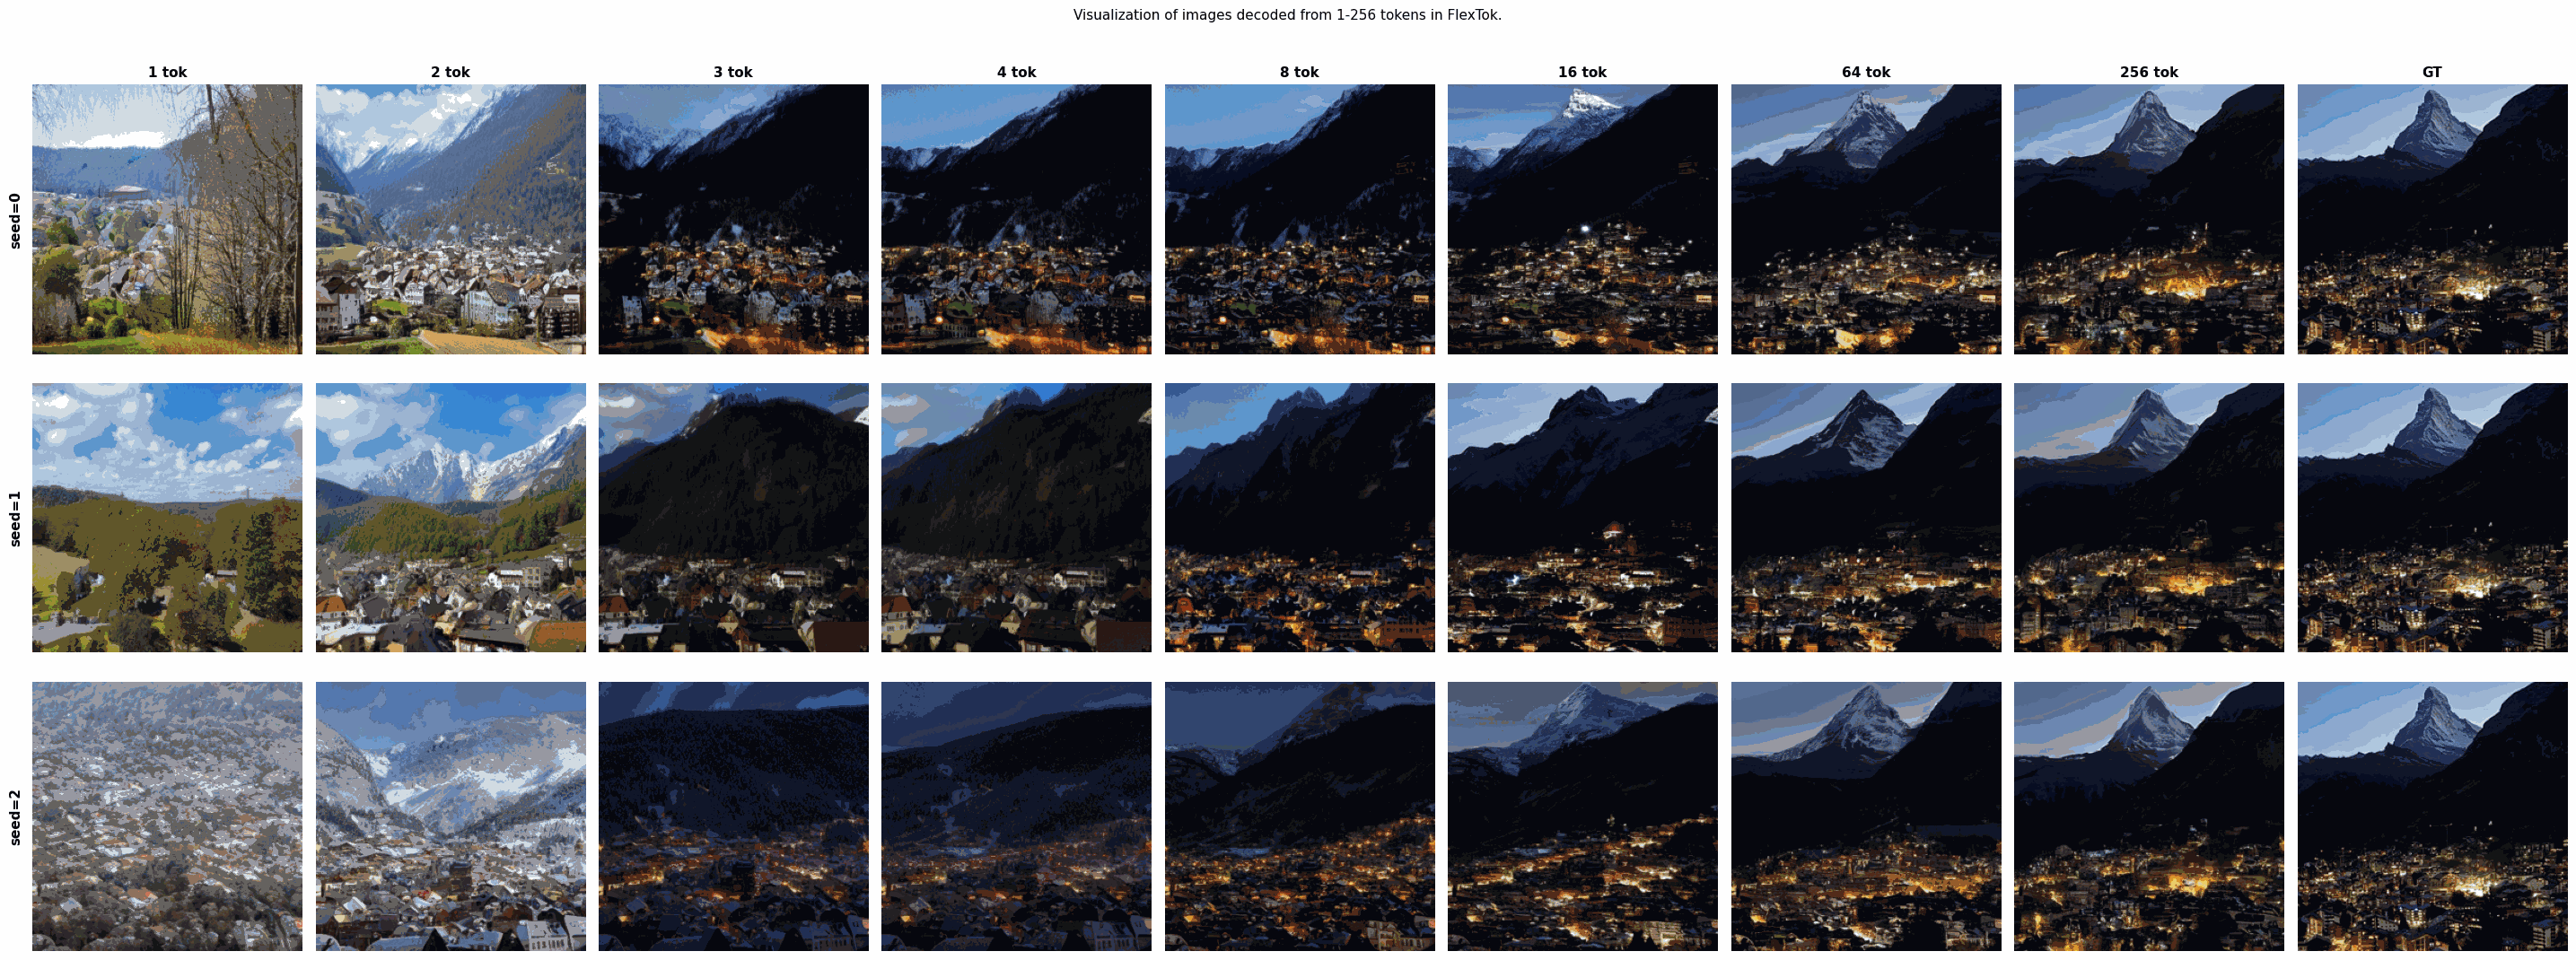

In [4]:
imgs = load_img('img/flex_tok_demo.png', device=device)

flextok = FlexTokFromHub.from_pretrained('EPFL-VILAB/flextok_d18_d28_dfn').to(device).eval()

k_keep_list, seeds = [1, 2, 3, 4, 8, 16, 64, 256], [0,1,2]
enable_bf16 = detect_bf16_support()

# Tokenization: encode the image into 256 FlexTok tokens (coarse-to-fine order)
with get_bf16_context(enable_bf16):
    tokens_list = flextok.tokenize(imgs)

token_ids = tokens_list[0][0].tolist()  # all 256 token IDs for the single image
print("First 4 tokens:", token_ids[:4])

# Detokenization: decode k-token prefixes across multiple seeds
tok_imgs = {}
for k_keep in k_keep_list:
    subseq_list = [seq[:, :k_keep].clone() for seq in tokens_list]
    for seed in seeds:
        with get_bf16_context(enable_bf16):
            tok_imgs[(k_keep, seed)] = flextok.detokenize(
                subseq_list, timesteps=15, guidance_scale=7.5, perform_norm_guidance=True,
                generator=get_generator(seed=seed, device=device), verbose=False)

to_pil = lambda t: TF.to_pil_image(denormalize(t).clamp(0, 1)[0])

show_rows(
    [(f"seed={s}", [to_pil(tok_imgs[(k, s)]) for k in k_keep_list] + [to_pil(imgs)], None)
     for s in seeds],
    col_titles=[f"{k} tok" for k in k_keep_list] + ["GT"],
    title="Visualization of images decoded from 1-256 tokens in FlexTok.",
)



## 2. Zero-Shot Generation by Beam Search

**Can we find good token sequences without a text-conditioned AR model?**

We use the **Uniform Prior** as the token generator: it samples tokens uniformly at random from the 64,000-token vocabulary, with no text conditioning. At each step, `beam_width × candidates_per_beam` random token extensions are decoded and scored by ImageReward; the best are kept as beams for the next step.

This is purely search-based generation, no AR model required.

In [5]:
# Load Uniform Prior (FlexTok tokenizer only — no AR model)
# The uniform prior samples tokens uniformly at random from the 64,000-token vocabulary.

uniform_prior = ARPriorFactory.create("uniform", device=device)
uniform_prior.set_seed(0)
print(f"Uniform prior loaded! Vocab size: {uniform_prior.vocab_size:,}, Max tokens: {uniform_prior.max_tokens}")


Uniform prior loaded! Vocab size: 64,000, Max tokens: 256


### 2.1 Setup

The **Uniform Prior** replaces the AR model: instead of sampling from a learned conditional distribution, it draws tokens uniformly at random from the 64,000-token vocabulary. All text-alignment is provided entirely by the verifier.

In [6]:
# Load ImageReward verifier
verifier = VerifierFactory.create("image_reward", device=device)


In [7]:
prompt = "A mountain village at dusk beneath a towering snow-capped peak."
# Other prompts to try:
# prompt = "A slice of bread next to a knife on a wooden table, sketch"
# prompt = "A painting of a vase to the right of a book."
# prompt = "A vase with greenery and white flowers on a wooden surface."
# prompt = "A painting of a snowy mountain at sunset."

beam_width = 3           # beams carried forward between steps
candidates_per_beam = 200  # candidates sampled per beam per step (~1% of 64k vocab)
num_results = 5          # top results to display at each step

# One searcher instance reused across all steps.
# scale_first_step=True: step 1 has only 1 active beam, so its candidate budget is
#   scaled to beam_width × candidates_per_beam to keep the total constant across steps.
searcher = SearchAlgorithmFactory.create(
    "beam", uniform_prior, verifier,
    {
        "beam_width": beam_width,
        "candidates_per_beam": candidates_per_beam,
        "token_schedule": "fixed",               # add exactly 1 token per step
        "max_steps": 1,                          # advance one token per call
        "decode_timesteps": 10,                  # flow-matching steps (lower = faster, less quality)
        "decode_batch_size": 160,                # images decoded per forward pass (tune for OOM)
        "scale_first_step": True,
    },
)

# Tips:
# - Increase candidates_per_beam (e.g. 500, 1k, 64k) for better results at the cost of speed.
# - Lower decode_timesteps (e.g. 10) speeds up search; raise to 15–25 for final quality.
# - Run more steps below to build longer token sequences (we show 4 steps here).

### 2.2 Step-by-Step Beam Search

We run beam search **one token at a time**, calling `searcher.search()` repeatedly and passing the previous result's tokens as `initial_tokens`. This lets us inspect intermediate results after each step.

The searcher is configured with `max_steps=1` so each call advances exactly one token. At each step, `beam_width × candidates_per_beam` random token extensions are sampled, decoded, and scored; only the top `beam_width` survive to the next step.

> **Note:** `scale_first_step=True` scales the candidate budget at step 1 (where only 1 beam is active) to `beam_width × candidates_per_beam` so the total candidates sampled is consistent across steps.

Step 1/1: 100%|██████████| 1/1 [03:16<00:00, 196.70s/step, score=-1.938, tokens=1]


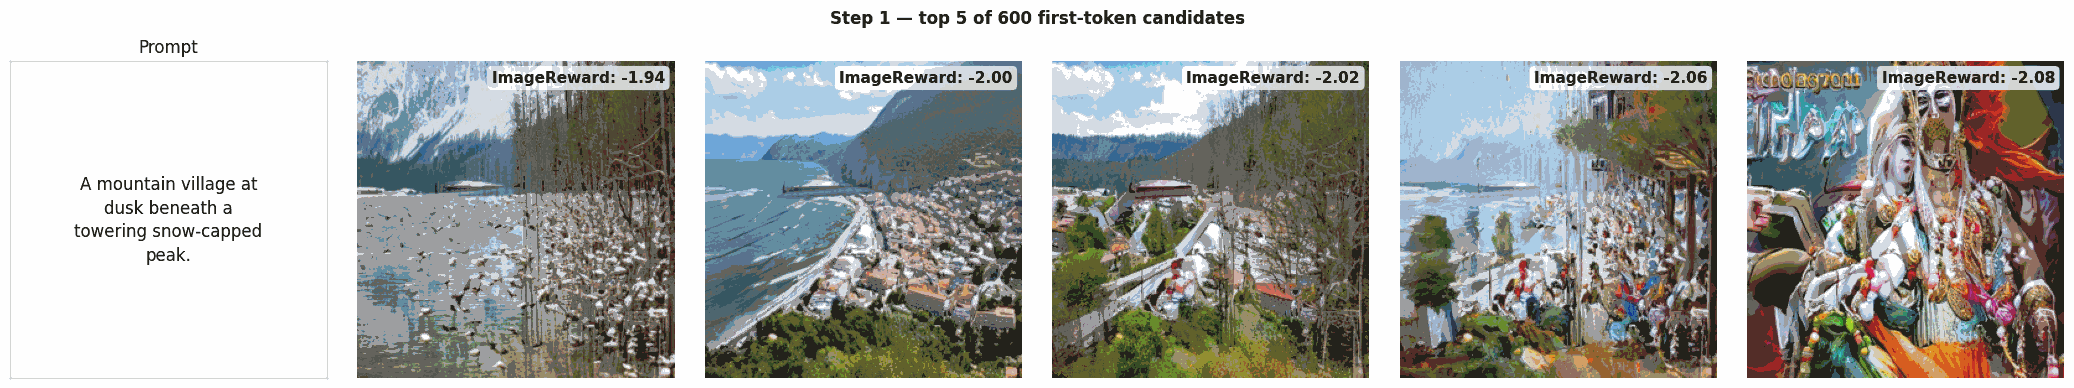

In [8]:
# Step 1 — sample beam_width × candidates_per_beam first tokens (scaled from 1 initial beam)
result1 = searcher.search(prompt, num_results=num_results, initial_tokens=None)
show_images(result1.images, overlay_labels=list(result1.scores), overlay_prefix="ImageReward",
            main_title=f"Step 1 — top {num_results} of {beam_width * candidates_per_beam} first-token candidates",
            prompt=prompt)

Step 1/1: 100%|██████████| 1/1 [03:13<00:00, 193.53s/step, score=-0.161, tokens=2]


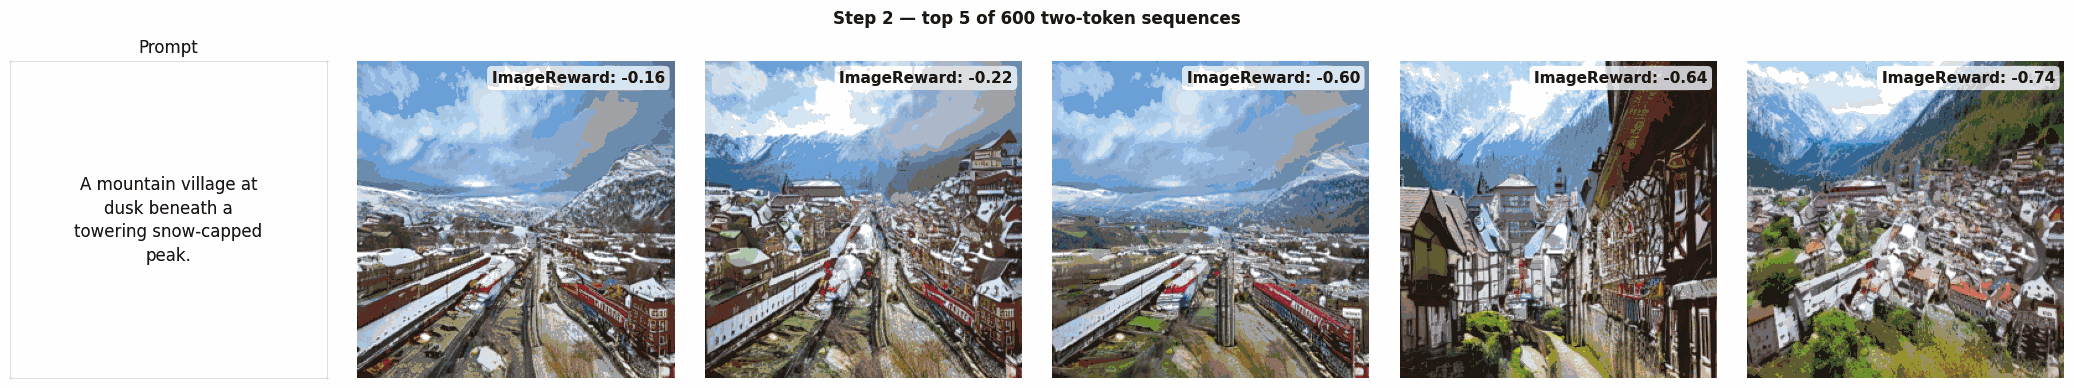

In [9]:
# Step 2
result2 = searcher.search(prompt, num_results=num_results, initial_tokens=result1.tokens)
show_images(result2.images, overlay_labels=list(result2.scores), overlay_prefix="ImageReward",
            main_title=f"Step 2 — top {num_results} of {beam_width * candidates_per_beam} two-token sequences",
            prompt=prompt)

Step 1/1: 100%|██████████| 1/1 [03:13<00:00, 193.71s/step, score=1.374, tokens=3]


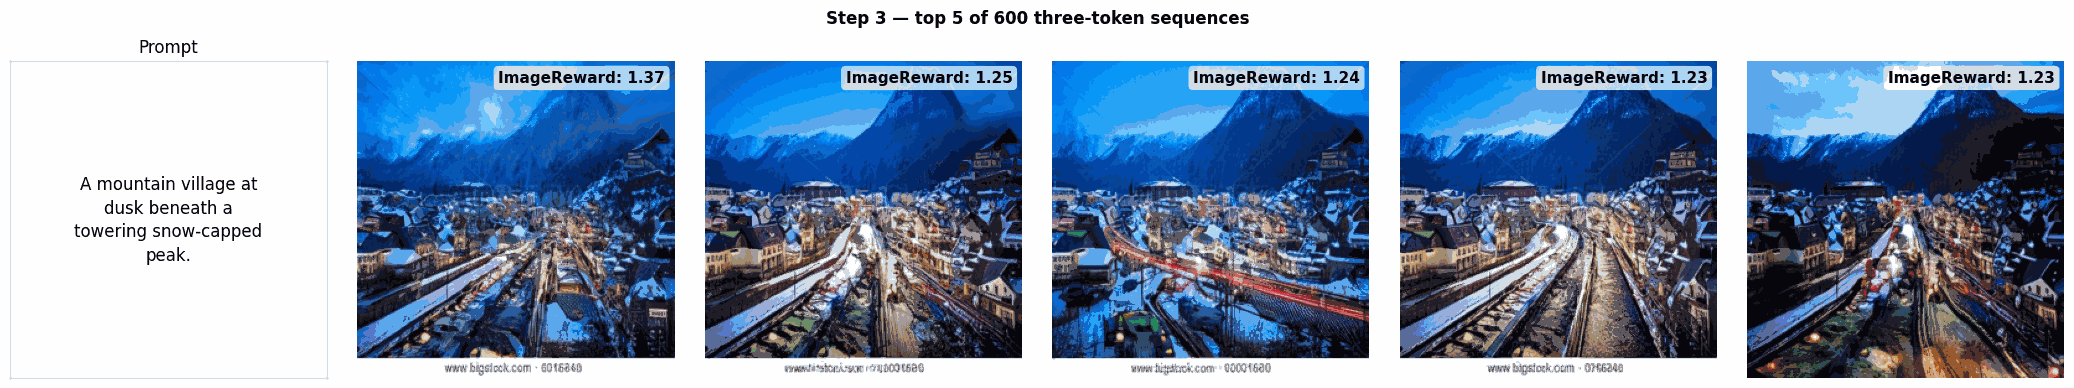

In [10]:
# Step 3
result3 = searcher.search(prompt, num_results=num_results, initial_tokens=result2.tokens)
show_images(result3.images, overlay_labels=list(result3.scores), overlay_prefix="ImageReward",
            main_title=f"Step 3 — top {num_results} of {beam_width * candidates_per_beam} three-token sequences",
            prompt=prompt)

Step 1/1: 100%|██████████| 1/1 [03:13<00:00, 193.30s/step, score=1.685, tokens=4]


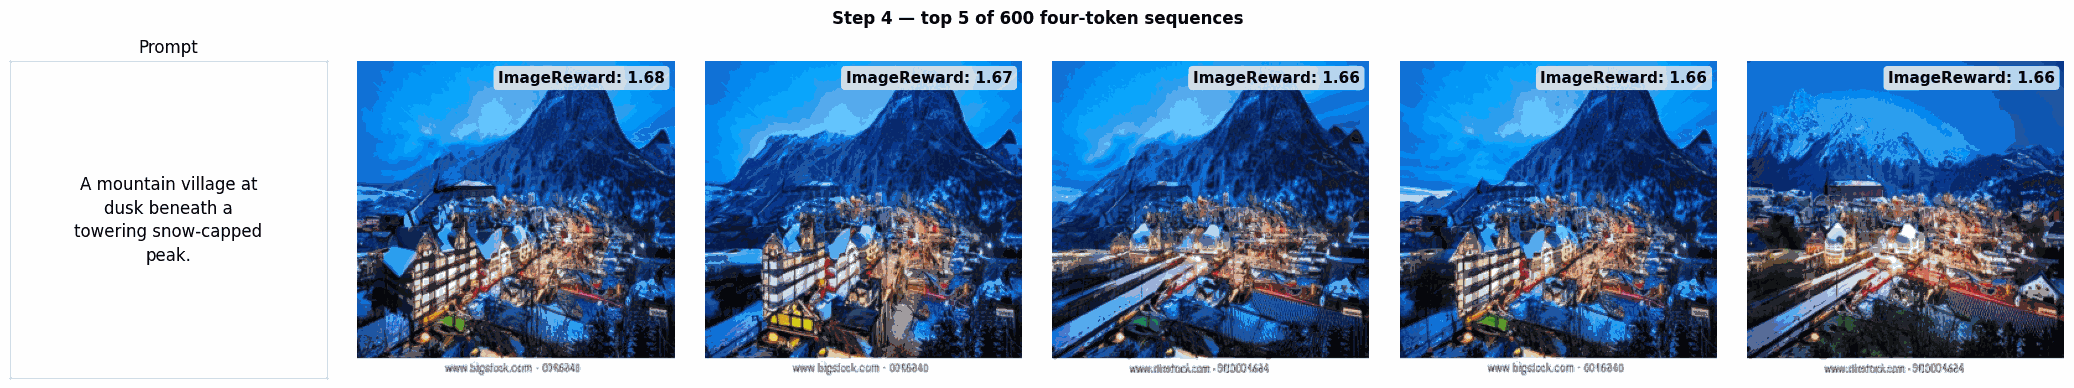

In [11]:
# Step 4
result4 = searcher.search(prompt, num_results=num_results, initial_tokens=result3.tokens)
show_images(result4.images, overlay_labels=list(result4.scores), overlay_prefix="ImageReward",
            main_title=f"Step 4 — top {num_results} of {beam_width * candidates_per_beam} four-token sequences",
            prompt=prompt)

### 2.3 Search Tree

`show_search_tree` visualizes the beam search decisions across all steps: each column is a step, each node is a candidate sequence, and surviving beams are connected across columns. This shows which token choices were kept and how the search progressively refines the output.

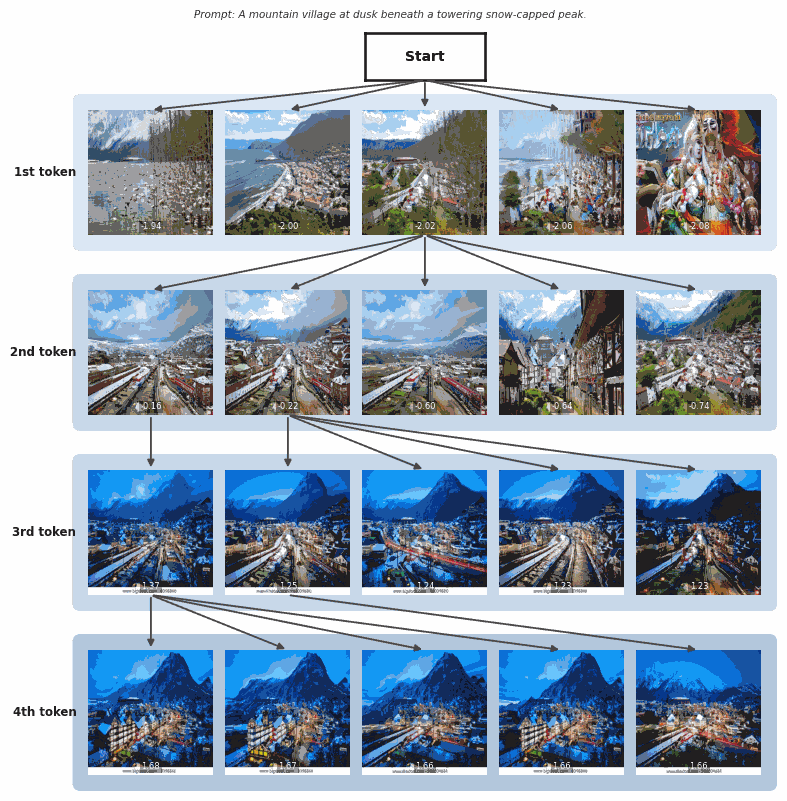

In [12]:
all_results = [result1, result2, result3, result4]
show_search_tree(all_results, prompt=prompt)


### 2.4 Search vs. GT Tokenization

We compare the search output at each step with the GT tokenization of the demo image (Section 1.2), decoded using the same number of tokens. The best image at each search step shares similarities with the corresponding k-token GT reconstruction.


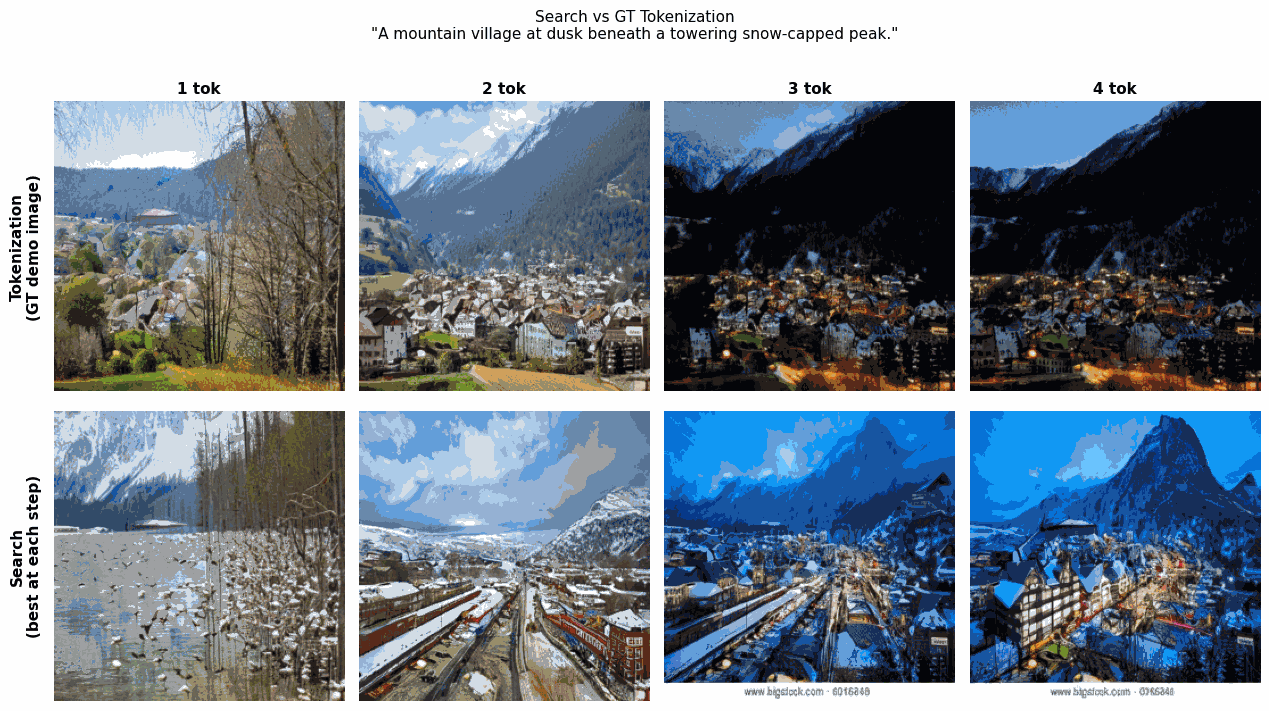

In [13]:
gt_tok_images = [to_pil(tok_imgs[(k, 0)]) for k in [1, 2, 3, 4]]
search_progressive = [result1.images[0], result2.images[0], result3.images[0], result4.images[0]]

show_rows(
    [
        ("Tokenization\n(GT demo image)", gt_tok_images,      None),
        ("Search\n(best at each step)",   search_progressive, None),
    ],
    col_titles=["1 tok", "2 tok", "3 tok", "4 tok"],
    title=f'Search vs GT Tokenization\n"{prompt}"',
)

## Takeaways
- FlexTok has a coarse-to-fine visual vocabulary that is amenable to search: the first token defines global concepts, and later tokens further refine them.
- It is possible to generate an image by conducting beam search on FlexTok tokens guided by an image-text verifier.